# Process equipment weight screening with NeqSim

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/weightofoilprocess.ipynb)

This tutorial connects a three-stage oil-stabilization simulation to NeqSim's
current mechanical-design system. It preserves the original offshore process
basis and schematic while replacing the unavailable serialized process file
with a transparent, reproducible model.


## Audience, prerequisites, and learning objectives

**Audience.** Process, facilities, and mechanical engineers who need early
weight and footprint screening for offshore or modular facilities.

**Prerequisites.** Familiarity with flashes, separators, compressors, pumps,
and Python is useful. No local files or proprietary data are required.

By the end, you will be able to:

1. build a realistic HP/MP/LP oil process with current NeqSim APIs;
2. close gas, oil, and water balances before mechanical sizing;
3. run equipment and system mechanical-design calculations;
4. retrieve vessel dimensions, dry weights, discipline breakdowns, and utilities;
5. evaluate how capacity changes affect separator size and process weight; and
6. distinguish study screening from certified detailed design.


In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    install_command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--upgrade",
        "--no-cache-dir",
        "neqsim",
    ]
    subprocess.run(install_command, check=True)


## Documentation and provenance

The original notebook downloaded `offshorePro.neqsim` from the retired
`equinor/neqsimprocess` repository and opened that hidden serialized model.
It then called the misspelled legacy method `getMechhanicalWeight`. The remote
file is no longer a safe, reproducible dependency, and the stored final output
described entropy rather than equipment weight.

This revision keeps the same engineering topic, process pressures,
temperatures, efficiencies, recompression stages, water letdown, and embedded
process diagram. The model is rebuilt below from explicit public inputs with
supported NeqSim 3.16 APIs.


## Engineering context

Weight is a first-order constraint for offshore topsides, floating production
facilities, transportable modules, and brownfield tie-ins. A credible screening
workflow must couple process conditions to equipment design: pressure,
temperature, phase flow, density, and duty influence vessel walls, rotating
equipment, piping allowances, structural steel, and plot space.

The calculation sequence is:

1. solve thermodynamics and the process flowsheet;
2. verify product balances and operating conditions;
3. initialize each unit's mechanical-design object;
4. calculate equipment designs; and
5. aggregate weights, dimensions, plot space, and utility loads.


In [2]:
import json
import math
import platform
import time
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import FancyBboxPatch

from neqsim.process import clearProcess
from neqsim.process import compressor
from neqsim.process import cooler
from neqsim.process import getProcess
from neqsim.process import heater
from neqsim.process import mixer
from neqsim.process import pump
from neqsim.process import runProcess
from neqsim.process import separator3phase
from neqsim.process import stream
from neqsim.process import valve
from neqsim.thermo import TPflash
from neqsim.thermo import fluid

java_result = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
)
java_version = java_result.stderr.splitlines()[0]

print(f"NeqSim version: {version('neqsim')}")
print(f"Python version: {platform.python_version()}")
print(f"Java runtime: {java_version}")


NeqSim version: 3.16.0
Python version: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


## How NeqSim represents this facility

A NeqSim `fluid` contains components, an equation of state, and mixing rules.
A `stream` carries that thermodynamic state and flow rate. Unit operations
transform streams: valves perform isenthalpic letdown, three-phase separators
split gas, oil, and water, compressors and pumps add shaft work, coolers and
heaters exchange heat, and mixers recombine compatible streams.

`runProcess()` solves units in flowsheet order. After convergence,
`runMechanicalDesignAndCostEstimation()` initializes equipment design objects,
calls their design calculations, aggregates results in
`SystemMechanicalDesign`, and prepares a study-class cost estimate.


In [3]:
design_basis = {
    "feed standard flow [MSm³/day]": 12.23,
    "feed temperature [°C]": 65.0,
    "feed pressure [bara]": 120.0,
    "inlet-conditioner temperature [°C]": 66.0,
    "inlet-conditioner pressure [bara]": 52.21,
    "HP separator pressure [bara]": 51.21,
    "oil-heater outlet temperature [°C]": 85.0,
    "MP separator pressure [bara]": 15.0,
    "LP separator pressure [bara]": 1.8,
    "produced-water outlet pressure [bara]": 1.01325,
    "gas-cooler outlet temperature [°C]": 33.0,
    "gas export pressure [bara]": 160.0,
    "oil export pressure [bara]": 20.0,
    "compressor isentropic efficiency [-]": 0.75,
    "pump isentropic efficiency [-]": 0.75,
}

basis_table = pd.DataFrame(
    {
        "Design variable": list(design_basis),
        "Value": list(design_basis.values()),
    }
)
display(basis_table)


,Design variable,Value
0,feed standard flow [MSm³/day],12.23000
1,feed temperature [°C],65.00000
2,feed pressure [bara],120.00000
3,inlet-conditioner temperature [°C],66.00000
4,inlet-conditioner pressure [bara],52.21000
5,HP separator pressure [bara],51.21000
6,oil-heater outlet temperature [°C],85.00000
7,MP separator pressure [bara],15.00000
8,LP separator pressure [bara],1.80000
9,produced-water outlet pressure [bara],1.01325


## Thermodynamic basis and validity limits

The Peng–Robinson equation of state is used because it is a standard
engineering model for hydrocarbon phase behavior over this pressure range.
Heavy fractions are represented as characterized TBP pseudo-components.
Water is included so the three-phase separators and produced-water branch are
exercised.

For every equilibrium stage, NeqSim enforces equality of component fugacity:

$$

f_i^{g} = f_i^{o} = f_i^{w}

$$

Here, $f_i$ is component $i$ fugacity in gas $g$, oil $o$, or water $w$.
The feed is synthetic and is suitable for teaching and concept screening,
not custody transfer, final equipment procurement, or safety certification.


In [4]:
defined_components = {
    "nitrogen": 0.3,
    "CO2": 0.8,
    "methane": 37.0,
    "ethane": 8.0,
    "propane": 6.0,
    "i-butane": 2.5,
    "n-butane": 3.5,
    "i-pentane": 2.0,
    "n-pentane": 2.5,
    "water": 1.5,
}

tbp_components = [
    ("C6", 4.5, 0.086, 690.0),
    ("C7", 5.0, 0.100, 720.0),
    ("C8", 5.5, 0.114, 745.0),
    ("C9", 5.5, 0.128, 765.0),
    ("C10", 5.0, 0.142, 785.0),
    ("C12", 5.0, 0.170, 810.0),
    ("C15", 4.5, 0.215, 840.0),
    ("C20", 3.9, 0.300, 880.0),
]

composition_table = pd.DataFrame(
    [
        {
            "Component": name,
            "Relative amount [mol]": amount,
            "Molar mass [kg/mol]": np.nan,
            "Liquid density [kg/m³]": np.nan,
        }
        for name, amount in defined_components.items()
    ]
)
composition_table["Relative amount [mol]"] = list(
    defined_components.values()
)

for name, amount, molar_mass, density_kg_m3 in tbp_components:
    composition_table.loc[len(composition_table)] = {
        "Component": name,
        "Relative amount [mol]": amount,
        "Molar mass [kg/mol]": molar_mass,
        "Liquid density [kg/m³]": density_kg_m3,
    }

display(composition_table)


,Component,Relative amount [mol],Molar mass [kg/mol],Liquid density [kg/m³]
0,nitrogen,0.3,NaN,NaN
1,CO2,0.8,NaN,NaN
2,methane,37.0,NaN,NaN
3,ethane,8.0,NaN,NaN
4,propane,6.0,NaN,NaN
5,i-butane,2.5,NaN,NaN
6,n-butane,3.5,NaN,NaN
7,i-pentane,2.0,NaN,NaN
8,n-pentane,2.5,NaN,NaN
9,water,1.5,NaN,NaN


## Build and audit the feed fluid

Relative component amounts are normalized by NeqSim. The audit below performs
a TP flash at feed conditions and checks that the normalized composition closes.
This separates thermodynamic input validation from the later process model.


In [5]:
def build_feed_fluid():
    crude = fluid("pr")

    for component_name, relative_amount in defined_components.items():
        crude.addComponent(component_name, relative_amount)

    for name, amount, molar_mass, density_kg_m3 in tbp_components:
        crude.addTBPfraction(
            name,
            amount,
            molar_mass,
            density_kg_m3 / 1_000.0,
        )

    crude.setMixingRule(2)
    crude.init(0)
    return crude


feed_fluid_audit = build_feed_fluid()
feed_fluid_audit.setTemperature(
    design_basis["feed temperature [°C]"],
    "C",
)
feed_fluid_audit.setPressure(
    design_basis["feed pressure [bara]"],
    "bara",
)
TPflash(feed_fluid_audit)
feed_fluid_audit.initProperties()

normalized_sum = sum(
    feed_fluid_audit.getComponent(index).getz()
    for index in range(feed_fluid_audit.getNumberOfComponents())
)

assert math.isclose(normalized_sum, 1.0, rel_tol=0.0, abs_tol=1.0e-12)
assert feed_fluid_audit.getNumberOfPhases() >= 1

print(f"Model components: {feed_fluid_audit.getNumberOfComponents()}")
print(f"Normalized mole-fraction sum: {normalized_sum:.12f} [-]")
print(f"Feed phases: {feed_fluid_audit.getNumberOfPhases()} [-]")
print(f"Feed molar mass: {feed_fluid_audit.getMolarMass():.6f} kg/mol")


Model components: 18
Normalized mole-fraction sum: 1.000000000000 [-]
Feed phases: 2 [-]
Feed molar mass: 0.075323 kg/mol


## Replace the inaccessible serialized process

The original example used `openprocess("offshorePro.neqsim")`. The following
explicit model is the operational replacement. It preserves the original
design basis and topology: inlet conditioning, HP/MP/LP separation, oil
heating, two-stage flash-gas recompression with 33 °C coolers, gas export
compression, oil export pumping, and produced-water letdown.


In [6]:
legacy_source_status = {
    "legacy file": "offshorePro.neqsim",
    "legacy loader": "openprocess",
    "replacement": "explicit current NeqSim process model",
    "hidden local dependency": False,
}

display(pd.Series(legacy_source_status, name="Model provenance").to_frame())


,Model provenance
legacy file,offshorePro.neqsim
legacy loader,openprocess
replacement,explicit current NeqSim process model
hidden local dependency,False


## figure oil process
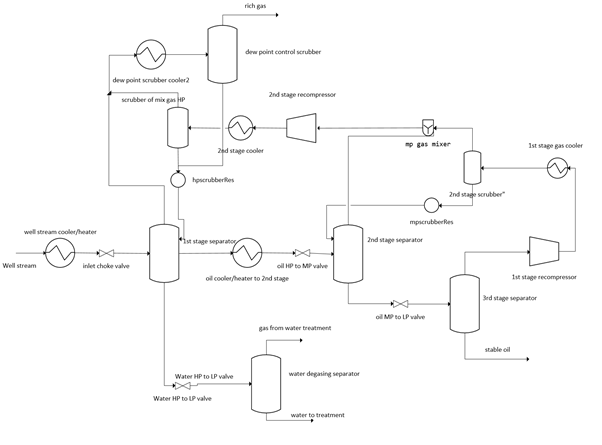

**Legacy visual inventory.** The embedded image above is the original notebook's
process schematic and is preserved unchanged as a historical teaching aid. Its
numerical labels are not treated as recalculated NeqSim results. The executable
topology below is the source of current results, balances, sizes, and weights.


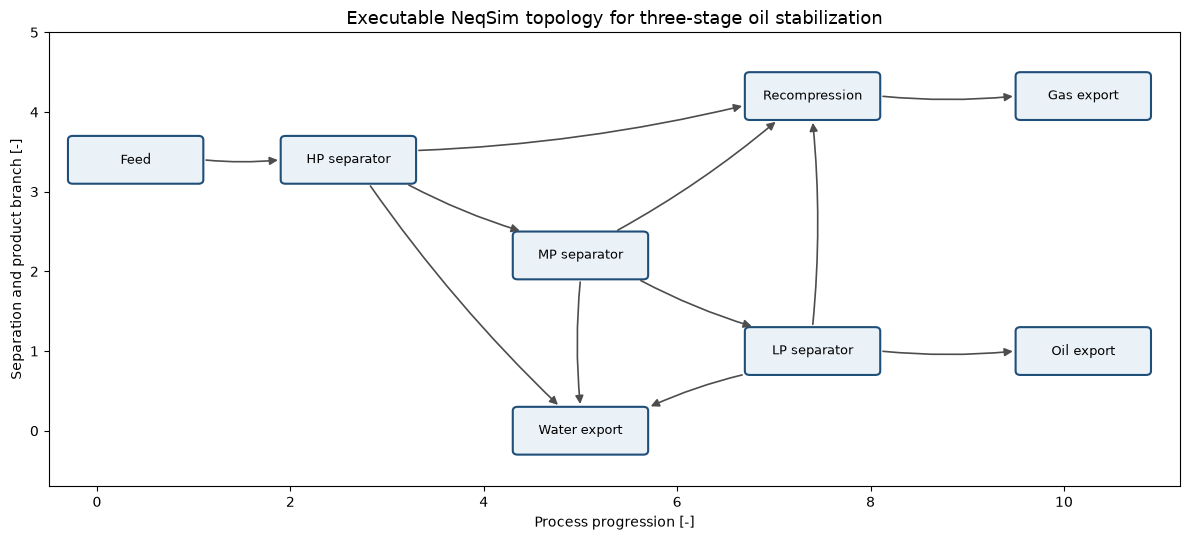

In [7]:
figure, axis = plt.subplots(figsize=(12, 5.5))

nodes = {
    "Feed": (0.4, 3.4),
    "HP separator": (2.6, 3.4),
    "MP separator": (5.0, 2.2),
    "LP separator": (7.4, 1.0),
    "Oil export": (10.2, 1.0),
    "Recompression": (7.4, 4.2),
    "Gas export": (10.2, 4.2),
    "Water export": (5.0, 0.0),
}

for label, (x_position, y_position) in nodes.items():
    box = FancyBboxPatch(
        (x_position - 0.65, y_position - 0.25),
        1.3,
        0.5,
        boxstyle="round,pad=0.05",
        facecolor="#EAF2F8",
        edgecolor="#1F4E79",
        linewidth=1.5,
    )
    axis.add_patch(box)
    axis.text(
        x_position,
        y_position,
        label,
        ha="center",
        va="center",
        fontsize=9,
    )

connections = [
    ("Feed", "HP separator"),
    ("HP separator", "MP separator"),
    ("MP separator", "LP separator"),
    ("LP separator", "Oil export"),
    ("LP separator", "Recompression"),
    ("MP separator", "Recompression"),
    ("HP separator", "Recompression"),
    ("Recompression", "Gas export"),
    ("HP separator", "Water export"),
    ("MP separator", "Water export"),
    ("LP separator", "Water export"),
]

box_half_width = 0.70
box_half_height = 0.30

def edge_point(source_point, destination_point):
    delta_x = destination_point[0] - source_point[0]
    delta_y = destination_point[1] - source_point[1]
    horizontal_scale = (
        box_half_width / abs(delta_x)
        if delta_x != 0.0
        else math.inf
    )
    vertical_scale = (
        box_half_height / abs(delta_y)
        if delta_y != 0.0
        else math.inf
    )
    scale = min(horizontal_scale, vertical_scale)
    return (
        source_point[0] + scale * delta_x,
        source_point[1] + scale * delta_y,
    )


for source, destination in connections:
    start = edge_point(nodes[source], nodes[destination])
    end = edge_point(nodes[destination], nodes[source])
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=12,
        color="#4D4D4D",
        linewidth=1.2,
        connectionstyle="arc3,rad=0.05",
    )
    axis.add_patch(arrow)

axis.set_title(
    "Executable NeqSim topology for three-stage oil stabilization",
    fontsize=13,
)
axis.set_xlim(-0.5, 11.2)
axis.set_ylim(-0.7, 5.0)
axis.set_xlabel("Process progression [-]")
axis.set_ylabel("Separation and product branch [-]")
axis.grid(False)
plt.tight_layout()
plt.show()


The executable diagram makes the dependency order explicit. Oil flows downward
through decreasing separator pressures. Flash gas is recompressed and cooled
before joining the HP gas, while water from each stage is let down separately
before mixing. This avoids mixing streams at incompatible pressures.


In [8]:
def build_process_case(
    feed_rate_msm3_day=design_basis["feed standard flow [MSm³/day]"],
):
    clearProcess()

    well_stream = stream("well stream", build_feed_fluid())
    well_stream.setFlowRate(feed_rate_msm3_day, "MSm3/day")
    well_stream.setTemperature(
        design_basis["feed temperature [°C]"],
        "C",
    )
    well_stream.setPressure(
        design_basis["feed pressure [bara]"],
        "bara",
    )

    inlet_conditioner = heater("inlet conditioner", well_stream)
    inlet_conditioner.setOutTemperature(
        design_basis["inlet-conditioner temperature [°C]"],
        "C",
    )
    inlet_conditioner.setOutPressure(
        design_basis["inlet-conditioner pressure [bara]"],
        "bara",
    )

    inlet_choke = valve(
        "inlet choke",
        inlet_conditioner.getOutStream(),
    )
    inlet_choke.setOutletPressure(
        design_basis["HP separator pressure [bara]"],
        "bara",
    )

    hp_separator = separator3phase(
        "HP separator",
        inlet_choke.getOutStream(),
    )
    hp_separator.setEntrainment(
        0.1,
        "volume",
        "product",
        "oil",
        "aqueous",
    )

    oil_heater = heater(
        "oil heater",
        hp_separator.getOilOutStream(),
    )
    oil_heater.setOutTemperature(
        design_basis["oil-heater outlet temperature [°C]"],
        "C",
    )

    hp_to_mp_valve = valve(
        "HP-to-MP oil valve",
        oil_heater.getOutStream(),
    )
    hp_to_mp_valve.setOutletPressure(
        design_basis["MP separator pressure [bara]"],
        "bara",
    )
    mp_separator = separator3phase(
        "MP separator",
        hp_to_mp_valve.getOutStream(),
    )

    mp_to_lp_valve = valve(
        "MP-to-LP oil valve",
        mp_separator.getOilOutStream(),
    )
    mp_to_lp_valve.setOutletPressure(
        design_basis["LP separator pressure [bara]"],
        "bara",
    )
    lp_separator = separator3phase(
        "LP separator",
        mp_to_lp_valve.getOutStream(),
    )

    oil_export_pump = pump(
        "oil export pump",
        lp_separator.getOilOutStream(),
    )
    oil_export_pump.setOutletPressure(
        design_basis["oil export pressure [bara]"],
        "bara",
    )
    oil_export_pump.setIsentropicEfficiency(
        design_basis["pump isentropic efficiency [-]"],
    )

    first_recompressor = compressor(
        "first-stage recompressor",
        lp_separator.getGasOutStream(),
        design_basis["MP separator pressure [bara]"],
    )
    first_recompressor.setIsentropicEfficiency(
        design_basis["compressor isentropic efficiency [-]"],
    )
    first_stage_cooler = cooler(
        "first-stage gas cooler",
        first_recompressor.getOutStream(),
    )
    first_stage_cooler.setOutTemperature(
        design_basis["gas-cooler outlet temperature [°C]"],
        "C",
    )

    mp_gas_mixer = mixer("MP gas mixer")
    mp_gas_mixer.addStream(mp_separator.getGasOutStream())
    mp_gas_mixer.addStream(first_stage_cooler.getOutStream())

    second_recompressor = compressor(
        "second-stage recompressor",
        mp_gas_mixer.getOutStream(),
        design_basis["HP separator pressure [bara]"],
    )
    second_recompressor.setIsentropicEfficiency(
        design_basis["compressor isentropic efficiency [-]"],
    )
    second_stage_cooler = cooler(
        "second-stage gas cooler",
        second_recompressor.getOutStream(),
    )
    second_stage_cooler.setOutTemperature(
        design_basis["gas-cooler outlet temperature [°C]"],
        "C",
    )

    hp_gas_mixer = mixer("HP gas mixer")
    hp_gas_mixer.addStream(hp_separator.getGasOutStream())
    hp_gas_mixer.addStream(second_stage_cooler.getOutStream())

    gas_export_compressor = compressor(
        "gas export compressor",
        hp_gas_mixer.getOutStream(),
        design_basis["gas export pressure [bara]"],
    )
    gas_export_compressor.setIsentropicEfficiency(
        design_basis["compressor isentropic efficiency [-]"],
    )
    gas_export_cooler = cooler(
        "gas export aftercooler",
        gas_export_compressor.getOutStream(),
    )
    gas_export_cooler.setOutTemperature(
        design_basis["gas-cooler outlet temperature [°C]"],
        "C",
    )

    water_valves = []
    for stage_name, separator_unit in [
        ("HP", hp_separator),
        ("MP", mp_separator),
        ("LP", lp_separator),
    ]:
        water_valve = valve(
            f"{stage_name} produced-water valve",
            separator_unit.getWaterOutStream(),
        )
        water_valve.setOutletPressure(
            design_basis["produced-water outlet pressure [bara]"],
            "bara",
        )
        water_valves.append(water_valve)

    produced_water_mixer = mixer("produced-water export")
    for water_valve in water_valves:
        produced_water_mixer.addStream(water_valve.getOutStream())

    runProcess()

    return {
        "feed": well_stream,
        "HP separator": hp_separator,
        "MP separator": mp_separator,
        "LP separator": lp_separator,
        "oil export": oil_export_pump.getOutStream(),
        "gas export": gas_export_cooler.getOutStream(),
        "water export": produced_water_mixer.getOutStream(),
        "first-stage recompressor": first_recompressor,
        "second-stage recompressor": second_recompressor,
        "gas export compressor": gas_export_compressor,
        "oil export pump": oil_export_pump,
        "oil heater": oil_heater,
        "first-stage gas cooler": first_stage_cooler,
        "second-stage gas cooler": second_stage_cooler,
        "gas export aftercooler": gas_export_cooler,
        "process": getProcess(),
    }


## Run the complete process

NeqSim propagates each solved outlet state to downstream equipment. The timer
is informative only; runtime varies by Colab host. A successful solve must be
followed by engineering checks rather than accepted solely because no exception
occurred.


In [9]:
start_time = time.perf_counter()
base_case = build_process_case()
simulation_time_s = time.perf_counter() - start_time
GasOilProcess = base_case["process"]

print(f"Simulation run time: {simulation_time_s:.3f} s")
print(f"Unit operations: {GasOilProcess.getUnitOperations().size()} [-]")


Simulation run time: 0.640 s
Unit operations: 22 [-]


## Product balance and process interpretation

At steady state, total mass entering the process must equal total gas, oil, and
water leaving it:

$$

\dot{m}_{feed} = \dot{m}_{gas} + \dot{m}_{oil} + \dot{m}_{water}

$$

Here, $\dot{m}$ is mass flow in kg/s. The normalized residual below should be
close to zero; it includes all three product branches.


In [10]:
product_streams = {
    "Export gas": base_case["gas export"],
    "Export oil": base_case["oil export"],
    "Produced water": base_case["water export"],
}

feed_mass_flow_kg_s = base_case["feed"].getFlowRate("kg/sec")
product_rows = []

for product_name, product_stream in product_streams.items():
    product_rows.append(
        {
            "Product": product_name,
            "Mass flow [kg/s]": product_stream.getFlowRate("kg/sec"),
            "Temperature [°C]": product_stream.getTemperature("C"),
            "Pressure [bara]": product_stream.getPressure("bara"),
        }
    )

product_table = pd.DataFrame(product_rows)
product_mass_flow_kg_s = product_table["Mass flow [kg/s]"].sum()
mass_balance_residual = (
    product_mass_flow_kg_s - feed_mass_flow_kg_s
) / feed_mass_flow_kg_s

assert np.isfinite(product_table["Mass flow [kg/s]"]).all()
assert (product_table["Mass flow [kg/s]"] >= 0.0).all()
assert abs(mass_balance_residual) < 1.0e-8

display(product_table)
print(f"Feed mass flow: {feed_mass_flow_kg_s:.3f} kg/s")
print(f"Normalized mass-balance residual: {mass_balance_residual:.3e} [-]")


Feed mass flow: 450.926 kg/s
Normalized mass-balance residual: -5.057e-12 [-]


,Product,Mass flow [kg/s],Temperature [°C],Pressure [bara]
0,Export gas,93.658051,33.000000,160.00000
1,Export oil,356.444833,69.847571,20.00000
2,Produced water,0.822737,65.826332,1.01325


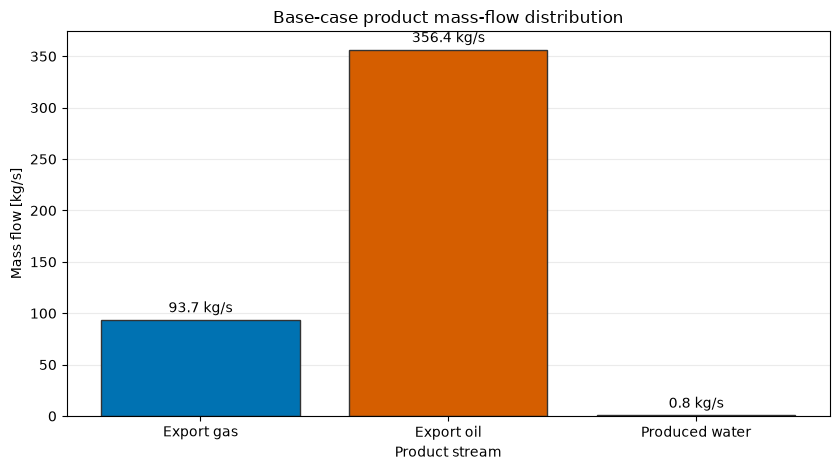

In [11]:
figure, axis = plt.subplots(figsize=(8.5, 4.8))
colors = ["#0072B2", "#D55E00", "#009E73"]

bars = axis.bar(
    product_table["Product"],
    product_table["Mass flow [kg/s]"],
    color=colors,
    edgecolor="#333333",
)
axis.bar_label(bars, fmt="%.1f kg/s", padding=3)
axis.set_title("Base-case product mass-flow distribution")
axis.set_xlabel("Product stream")
axis.set_ylabel("Mass flow [kg/s]")
axis.grid(axis="y", alpha=0.25)
axis.set_axisbelow(True)
plt.tight_layout()
plt.show()


The product distribution is calculated from the current NeqSim solution, not
copied from the legacy image. Export oil dominates the mass basis for this
synthetic fluid, while gas and produced water remain explicit balance terms.


In [12]:
utility_rows = []

for equipment_name in [
    "first-stage recompressor",
    "second-stage recompressor",
    "gas export compressor",
    "oil export pump",
]:
    equipment = base_case[equipment_name]
    utility_rows.append(
        {
            "Equipment": equipment_name,
            "Service": "Shaft power",
            "Load [kW]": abs(equipment.getPower("kW")),
        }
    )

for equipment_name in [
    "oil heater",
    "first-stage gas cooler",
    "second-stage gas cooler",
    "gas export aftercooler",
]:
    equipment = base_case[equipment_name]
    utility_rows.append(
        {
            "Equipment": equipment_name,
            "Service": "Heat duty",
            "Load [kW]": abs(equipment.getDuty()) / 1_000.0,
        }
    )

utility_table = pd.DataFrame(utility_rows)
assert np.isfinite(utility_table["Load [kW]"]).all()
assert (utility_table["Load [kW]"] >= 0.0).all()
display(utility_table)


,Equipment,Service,Load [kW]
0,first-stage recompressor,Shaft power,5202.329310
1,second-stage recompressor,Shaft power,6106.320519
2,gas export compressor,Shaft power,11067.752341
3,oil export pump,Shaft power,1228.326394
4,oil heater,Heat duty,18311.657177
5,first-stage gas cooler,Heat duty,14513.922949
6,second-stage gas cooler,Heat duty,18422.007048
7,gas export aftercooler,Heat duty,27386.436489


Utility loads are valuable design context: compressor power and exchanger duty
affect package weight even when pressure-vessel sizing dominates an individual
separator. NeqSim's system mechanical report aggregates these loads alongside
equipment weights and plot space.


## Mechanical-design theory

A pressure-vessel screening calculation links process state to geometry and
material. A simplified cylindrical-shell relation illustrates the dependency:

$$

m_{shell} = \rho_s \pi D L t

$$

Here, $m_{shell}$ is shell mass in kg, $\rho_s$ is steel density in kg/m³,
$D$ is diameter in m, $L$ is tangent length in m, and $t$ is wall thickness in
m. NeqSim's separator design adds heads, nozzles, internals, piping,
instrumentation, and structural allowances. The system total is:

$$

m_{system} = \sum_j m_j

$$

where $m_j$ is the calculated total weight of equipment item $j$.


# Estimation of process weights

This retained section now uses the current supported workflow. The process is
solved first, then all equipment mechanical designs and the whole-process
aggregator are run. Results are parsed from NeqSim's structured JSON report
rather than from stale text output.


In [13]:
GasOilProcess.runMechanicalDesignAndCostEstimation()
mechanical_report = json.loads(
    str(GasOilProcess.getMechanicalDesignAndCostEstimateJson())
)

mechanical_summary = mechanical_report["mechanicalDesignSummary"]
weight_by_type = mechanical_report["weightByEquipmentType_kg"]
weight_by_discipline = mechanical_report["weightByDiscipline_kg"]

totalWeight = mechanical_summary["totalWeight_kg"]
weight_table = (
    pd.Series(weight_by_type, name="Weight [kg]")
    .rename_axis("Equipment type")
    .reset_index()
)
weight_table = weight_table[weight_table["Weight [kg]"] > 0.0]
weight_table = weight_table.sort_values(
    "Weight [kg]",
    ascending=False,
).reset_index(drop=True)

assert totalWeight > 0.0
assert np.isfinite(totalWeight)
assert math.isclose(
    weight_table["Weight [kg]"].sum(),
    totalWeight,
    rel_tol=1.0e-10,
)

print(f"Total calculated process weight: {totalWeight:,.0f} kg")
print(
    "Total plot space: "
    f"{mechanical_summary['totalPlotSpace_m2']:,.1f} m²"
)
display(weight_table)


Total calculated process weight: 467,288 kg
Total plot space: 484.0 m²


,Equipment type,Weight [kg]
0,Compressor,129982.328260
1,Mixer/Splitter,125181.614614
2,Separator,112490.660096
3,Heat Exchanger,70572.000000
4,Valve,22203.650079
5,Pump,6857.900010


The total is a NeqSim study-screening result. It includes each unit's native
mechanical-design allowances, so streams correctly contribute zero weight while
vessels, rotating equipment, valves, heat exchangers, and mixers contribute
according to their current design models. It is not a certified module lift
weight or a substitute for vendor data.


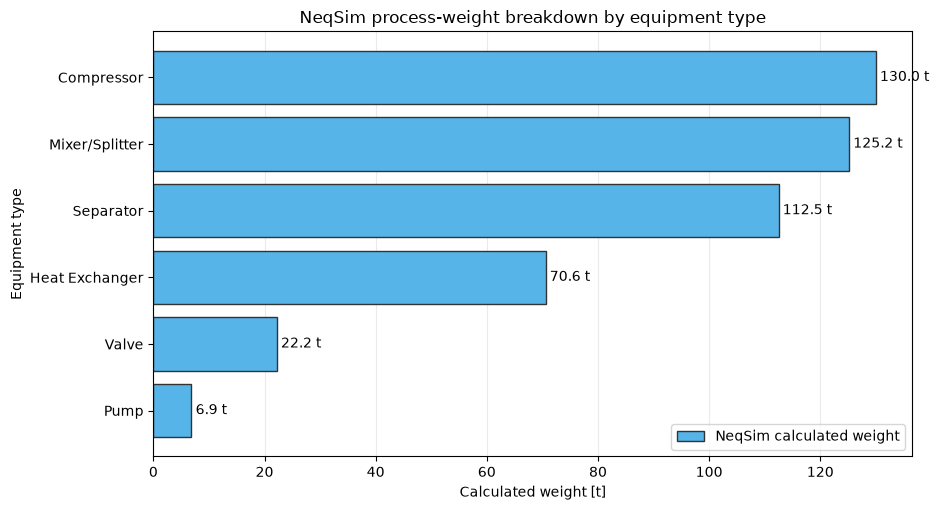

In [14]:
figure, axis = plt.subplots(figsize=(9.5, 5.2))
weight_plot = weight_table.sort_values("Weight [kg]")

bars = axis.barh(
    weight_plot["Equipment type"],
    weight_plot["Weight [kg]"] / 1_000.0,
    color="#56B4E9",
    edgecolor="#333333",
    label="NeqSim calculated weight",
)
axis.bar_label(bars, fmt="%.1f t", padding=3)
axis.set_title("NeqSim process-weight breakdown by equipment type")
axis.set_xlabel("Calculated weight [t]")
axis.set_ylabel("Equipment type")
axis.legend(loc="lower right")
axis.grid(axis="x", alpha=0.25)
axis.set_axisbelow(True)
plt.tight_layout()
plt.show()


The breakdown identifies where better project-specific data has the greatest
value. High-weight categories should be reconciled first with equipment lists,
vendor quotations, material selections, and module-layout assumptions.


In [15]:
discipline_table = (
    pd.Series(weight_by_discipline, name="Weight [kg]")
    .rename_axis("Discipline")
    .reset_index()
)
discipline_table["Share [%]"] = (
    100.0 * discipline_table["Weight [kg]"] / totalWeight
)

assert math.isclose(
    discipline_table["Weight [kg]"].sum(),
    totalWeight,
    rel_tol=1.0e-10,
)
assert math.isclose(
    discipline_table["Share [%]"].sum(),
    100.0,
    rel_tol=1.0e-10,
)
display(discipline_table)


,Discipline,Weight [kg],Share [%]
0,Mechanical Equipment,366537.090654,78.439200
1,Piping,62951.358177,13.471636
2,Electrical & Instrumentation,18530.281589,3.965494
3,Structural Steel,19269.422640,4.123670


Discipline weights expose the model's allowance structure. Mechanical
equipment is separated from associated piping, electrical and instrumentation,
and structural steel. This is more useful for early facility planning than one
undifferentiated total.


In [16]:
separator_rows = []

for separator_name in ["HP separator", "MP separator", "LP separator"]:
    separator_design = GasOilProcess.getEquipmentMechanicalDesign(
        separator_name
    )
    separator_rows.append(
        {
            "Separator": separator_name,
            "Total weight [kg]": separator_design.getWeightTotal(),
            "Inner diameter [m]": separator_design.getInnerDiameter(),
            "Tangent length [m]": separator_design.getTantanLength(),
            "Wall thickness [mm]": (
                1_000.0 * separator_design.getWallThickness()
            ),
        }
    )

separator_table = pd.DataFrame(separator_rows)

numeric_separator_results = separator_table.select_dtypes(
    include="number"
)
assert np.isfinite(numeric_separator_results.to_numpy()).all()
assert (numeric_separator_results.to_numpy() > 0.0).all()
display(separator_table)


,Separator,Total weight [kg],Inner diameter [m],Tangent length [m],Wall thickness [mm]
0,HP separator,17187.887145,1.843937,8.378523,22.004017
1,MP separator,16991.021330,1.911440,7.707880,22.809550
2,LP separator,78311.751621,2.960952,14.804758,35.333550


The LP separator can become the largest vessel because pressure letdown
generates more vapor and lower gas density increases volumetric flow. This is
an engineering trend, not an error: vessel capacity depends on phase volumetric
rates and densities, not mass flow alone.


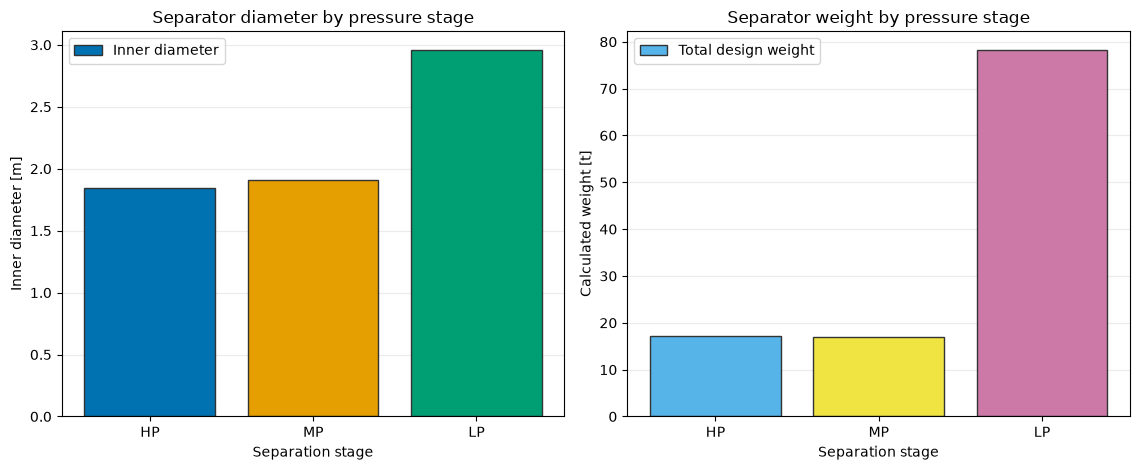

In [17]:
figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
separator_labels = separator_table["Separator"].str.replace(
    " separator",
    "",
    regex=False,
)

axes[0].bar(
    separator_labels,
    separator_table["Inner diameter [m]"],
    color=["#0072B2", "#E69F00", "#009E73"],
    edgecolor="#333333",
    label="Inner diameter",
)
axes[0].set_title("Separator diameter by pressure stage")
axes[0].set_xlabel("Separation stage")
axes[0].set_ylabel("Inner diameter [m]")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    separator_labels,
    separator_table["Total weight [kg]"] / 1_000.0,
    color=["#56B4E9", "#F0E442", "#CC79A7"],
    edgecolor="#333333",
    label="Total design weight",
)
axes[1].set_title("Separator weight by pressure stage")
axes[1].set_xlabel("Separation stage")
axes[1].set_ylabel("Calculated weight [t]")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

for axis in axes:
    axis.set_axisbelow(True)

plt.tight_layout()
plt.show()


## Capacity sensitivity

Early weight estimates must respond to design capacity. Three cases are rebuilt
from clean process objects at 75%, 100%, and 125% of base feed. Each case reruns
thermodynamics, process simulation, and native mechanical design; no plotted
point is scaled algebraically from the base result.


In [18]:
capacity_factors = np.array([0.75, 1.00, 1.25])
sensitivity_rows = []

for capacity_factor in capacity_factors:
    case_feed_rate = (
        capacity_factor
        * design_basis["feed standard flow [MSm³/day]"]
    )
    sensitivity_case = build_process_case(case_feed_rate)
    sensitivity_process = sensitivity_case["process"]
    sensitivity_process.runMechanicalDesignAndCostEstimation()

    sensitivity_report = json.loads(
        str(
            sensitivity_process
            .getMechanicalDesignAndCostEstimateJson()
        )
    )
    sensitivity_summary = sensitivity_report[
        "mechanicalDesignSummary"
    ]
    lp_design = sensitivity_process.getEquipmentMechanicalDesign(
        "LP separator"
    )

    sensitivity_rows.append(
        {
            "Capacity [%]": 100.0 * capacity_factor,
            "Feed rate [MSm³/day]": case_feed_rate,
            "Total weight [kg]": sensitivity_summary[
                "totalWeight_kg"
            ],
            "Plot space [m²]": sensitivity_summary[
                "totalPlotSpace_m2"
            ],
            "LP diameter [m]": lp_design.getInnerDiameter(),
        }
    )

sensitivity_table = pd.DataFrame(sensitivity_rows)
assert np.isfinite(
    sensitivity_table.select_dtypes(include="number").to_numpy()
).all()
assert sensitivity_table["Total weight [kg]"].is_monotonic_increasing
assert sensitivity_table["LP diameter [m]"].is_monotonic_increasing
display(sensitivity_table)


,Capacity [%],Feed rate [MSm³/day],Total weight [kg],Plot space [m²],LP diameter [m]
0,75.0,9.1725,393934.885612,400.313706,2.564259
1,100.0,12.2300,467288.153131,484.019393,2.960952
2,125.0,15.2875,544915.305775,560.223581,3.310444


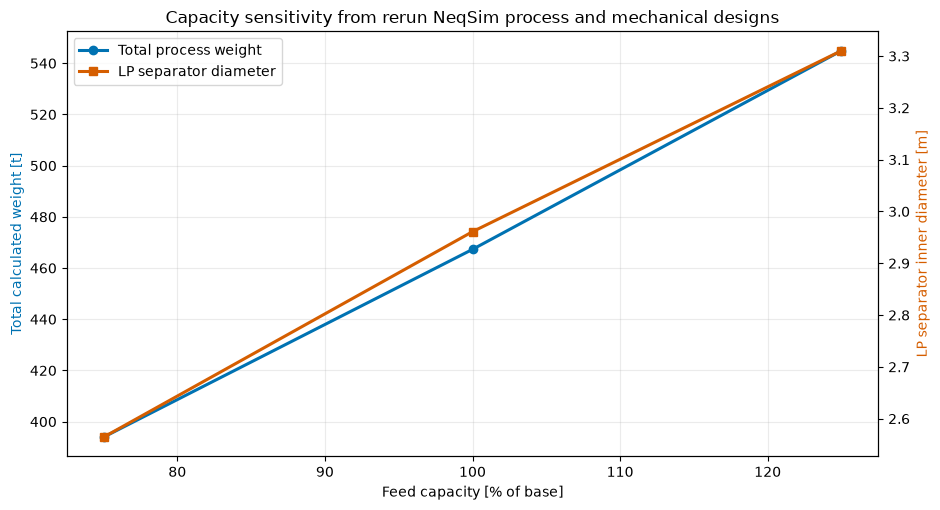

In [19]:
figure, primary_axis = plt.subplots(figsize=(9.5, 5.2))
secondary_axis = primary_axis.twinx()

weight_line = primary_axis.plot(
    sensitivity_table["Capacity [%]"],
    sensitivity_table["Total weight [kg]"] / 1_000.0,
    marker="o",
    linewidth=2.2,
    color="#0072B2",
    label="Total process weight",
)
diameter_line = secondary_axis.plot(
    sensitivity_table["Capacity [%]"],
    sensitivity_table["LP diameter [m]"],
    marker="s",
    linewidth=2.2,
    color="#D55E00",
    label="LP separator diameter",
)

primary_axis.set_title(
    "Capacity sensitivity from rerun NeqSim process and mechanical designs"
)
primary_axis.set_xlabel("Feed capacity [% of base]")
primary_axis.set_ylabel("Total calculated weight [t]", color="#0072B2")
secondary_axis.set_ylabel("LP separator inner diameter [m]", color="#D55E00")
primary_axis.grid(alpha=0.25)

lines = weight_line + diameter_line
primary_axis.legend(
    lines,
    [line.get_label() for line in lines],
    loc="upper left",
)
plt.tight_layout()
plt.show()


Both total weight and LP separator diameter increase with capacity in the
recalculated cases. The relationship is nonlinear because phase volumetric
rates, equipment duties, wall thicknesses, and design allowances change
together. Extrapolation outside the tested range is not recommended.


## Final application: reuse the workflow for a project case

The reusable function below turns a feed-rate assumption into a compact design
summary. In project work, replace the synthetic characterization, verify the
phase model against laboratory data, set company design standards and margins,
then compare NeqSim's screening output with vendor and layout information.


In [20]:
def summarize_process_weight(feed_rate_msm3_day):
    project_case = build_process_case(feed_rate_msm3_day)
    project_process = project_case["process"]
    project_process.runMechanicalDesignAndCostEstimation()
    project_report = json.loads(
        str(project_process.getMechanicalDesignAndCostEstimateJson())
    )
    summary = project_report["mechanicalDesignSummary"]

    return pd.Series(
        {
            "Feed rate [MSm³/day]": feed_rate_msm3_day,
            "Total weight [kg]": summary["totalWeight_kg"],
            "Total volume [m³]": summary["totalVolume_m3"],
            "Plot space [m²]": summary["totalPlotSpace_m2"],
            "Power required [kW]": summary[
                "totalPowerRequired_kW"
            ],
            "Heating duty [kW]": summary["totalHeatingDuty_kW"],
            "Cooling duty [kW]": summary["totalCoolingDuty_kW"],
        },
        name="NeqSim study result",
    )


example_project_summary = summarize_process_weight(10.0)
display(example_project_summary.to_frame())


,NeqSim study result
Feed rate [MSm³/day],10.000000
Total weight [kg],416243.245874
Total volume [m³],149.661397
Plot space [m²],424.020446
Power required [kW],19300.677497
Heating duty [kW],19739.789431
Cooling duty [kW],49323.275949


## Verification checks

The final gate checks composition, execution, balances, finite outputs,
dimensions, weight aggregation, discipline closure, and expected capacity
trends. These checks are focused engineering tests, not generic “cell ran”
indicators.


In [21]:
engineering_checks = {
    "composition closes": abs(normalized_sum - 1.0) < 1.0e-12,
    "process has units": GasOilProcess.getUnitOperations().size() >= 20,
    "feed flow is positive": feed_mass_flow_kg_s > 0.0,
    "three product streams exist": len(product_streams) == 3,
    "all product flows are finite": np.isfinite(
        product_table["Mass flow [kg/s]"]
    ).all(),
    "all product flows are nonnegative": (
        product_table["Mass flow [kg/s]"] >= 0.0
    ).all(),
    "mass closes": abs(mass_balance_residual) < 1.0e-8,
    "utility loads are finite": np.isfinite(
        utility_table["Load [kW]"]
    ).all(),
    "total weight is positive": totalWeight > 0.0,
    "total weight is finite": np.isfinite(totalWeight),
    "equipment weights close": math.isclose(
        weight_table["Weight [kg]"].sum(),
        totalWeight,
        rel_tol=1.0e-10,
    ),
    "discipline weights close": math.isclose(
        discipline_table["Weight [kg]"].sum(),
        totalWeight,
        rel_tol=1.0e-10,
    ),
    "discipline shares close": math.isclose(
        discipline_table["Share [%]"].sum(),
        100.0,
        rel_tol=1.0e-10,
    ),
    "separator results are finite": np.isfinite(
        numeric_separator_results.to_numpy()
    ).all(),
    "separator results are positive": (
        numeric_separator_results.to_numpy() > 0.0
    ).all(),
    "capacity weight trend holds": sensitivity_table[
        "Total weight [kg]"
    ].is_monotonic_increasing,
    "capacity diameter trend holds": sensitivity_table[
        "LP diameter [m]"
    ].is_monotonic_increasing,
    "screening example is finite": np.isfinite(
        example_project_summary.to_numpy(dtype=float)
    ).all(),
}

failed_checks = [
    name
    for name, passed in engineering_checks.items()
    if not bool(passed)
]

assert not failed_checks, f"Failed checks: {failed_checks}"
print(f"All {len(engineering_checks)} engineering checks passed.")


All 18 engineering checks passed.


## Limitations and applicability

- The fluid is synthetic; tune pseudo-components and binary interactions to PVT
  data before project decisions.
- Default NeqSim design standards are used. Set project material, corrosion,
  pressure, temperature, joint-efficiency, and company-standard inputs.
- The result is equipment-factored study screening. It excludes project-specific
  layout, access, lifting frames, winterization, fireproofing, flare structures,
  buildings, drilling facilities, contingencies, and vendor package details.
- Dynamic slugging, relief cases, fatigue, transportation, and structural
  verification require separate studies.
- The preserved legacy schematic is contextual; only executed cells provide
  refreshed numerical results.


## Troubleshooting

- **No aqueous phase:** increase the explicit water amount or verify the selected
  thermodynamic model and mixing rule.
- **A separator reports implausible dimensions:** inspect phase volumetric flows,
  density, pressure, temperature, orientation, retention-time assumptions, and
  design-standard settings.
- **A weight is zero:** confirm that the unit supports a mechanical-design class
  and that the process was solved before design calculations.
- **A balance fails:** include every terminal gas, oil, and water stream and use
  one consistent mass-flow unit.
- **A sensitivity trend is irregular:** rerun each case from a clean process and
  inspect phase changes rather than forcing monotonicity.


## Summary

This notebook repairs the original weight example without deleting its process
intent or visual. The unavailable serialized flowsheet is replaced by an
explicit HP/MP/LP NeqSim model. Current native functionality calculates
separator geometry, equipment and discipline weight breakdowns, plot space,
utilities, and a capacity sensitivity. Every result is regenerated from the
current process state and protected by focused assertions.


## Further exercises

1. Replace the synthetic fluid with a characterized laboratory composition and
   compare phase splits and vessel sizes.
2. Apply project design-pressure and temperature margins and quantify the effect
   on separator wall thickness and weight.
3. Compare vertical and horizontal separator designs at equal capacity.
4. Add inlet slug volume and retention-time constraints.
5. Reconcile the screening estimate with a vendor equipment list and document
   every excluded module-weight category.


## References

- [NeqSim repository and documentation](https://github.com/equinor/neqsim)
- [NeqSim Python package](https://pypi.org/project/neqsim/)
- [NeqSim process examples](https://github.com/equinor/neqsim/tree/master/src/test/java/neqsim/process)
- [SystemMechanicalDesign source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/mechanicaldesign/SystemMechanicalDesign.java)
- [SeparatorMechanicalDesign source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/mechanicaldesign/separator/SeparatorMechanicalDesign.java)

Consult the applicable pressure-vessel code, NORSOK requirements, company
specifications, and vendor data for project design.
